In [1]:
import numpy as np
import sqlite3
import pandas as pd
import matplotlib.pylab as plt
%matplotlib inline

import rubin_sim.splat as maf

In [2]:
filename = "baseline_v5.3.0_10yrs.db"
run_name = filename.replace(".db", "")
con = sqlite3.connect(filename)
df = pd.read_sql("select * from observations;", con)
con.close()


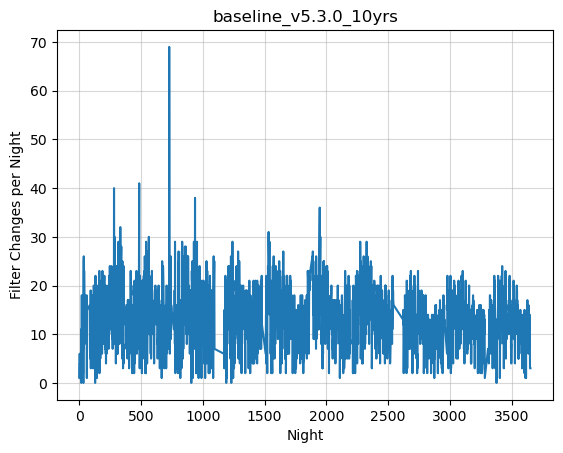

In [3]:
info = {"run_name": run_name, "metric: name": "filter changes"}
fpn = df.groupby("night")["filter"].apply(maf.count_value_changes)
pl = maf.PlotLine(info=info)
fig = pl(fpn.index, fpn.values, xlabel="Night", ylabel="Filter Changes per Night")

In [4]:
fpn.index[np.where(fpn.values > 60)]

Index([727], dtype='int64', name='night')

In [5]:
indx = np.where(df["night"] == 727)[0]
df["scheduler_note"].values[indx]

<ArrowStringArray>
['ToO, GW_case_D_E, g, 383, i0, 23627', 'ToO, GW_case_D_E, g, 383, i0, 23629',
 'ToO, GW_case_D_E, g, 383, i0, 23630', 'ToO, GW_case_D_E, g, 383, i0, 23635',
 'ToO, GW_case_D_E, g, 383, i0, 23636', 'ToO, GW_case_D_E, i, 383, i0, 23712',
 'ToO, GW_case_D_E, i, 383, i0, 23714', 'ToO, GW_case_D_E, i, 383, i0, 23715',
 'ToO, GW_case_D_E, i, 383, i0, 23720', 'ToO, GW_case_D_E, i, 383, i0, 23721',
 ...
 'ToO, GW_case_D_E, i, 383, i0, 23710',                            'greedy i',
                            'greedy i',                            'greedy i',
                            'greedy i',                            'greedy i',
 'ToO, GW_case_D_E, i, 383, i0, 23717', 'ToO, GW_case_D_E, g, 383, i0, 23632',
                            'greedy z', 'ToO, GW_case_D_E, g, 383, i0, 23641']
Length: 865, dtype: str

In [20]:
df["band"].values[indx][700:800]

<ArrowStringArray>
['z', 'z', 'z', 'z', 'z', 'z', 'z', 'z', 'z', 'z', 'z', 'z', 'z', 'z', 'z',
 'z', 'z', 'z', 'z', 'z', 'z', 'z', 'z', 'z', 'z', 'g', 'g', 'g', 'g', 'g',
 'g', 'g', 'g', 'g', 'g', 'g', 'g', 'g', 'i', 'i', 'i', 'i', 'i', 'i', 'i',
 'i', 'i', 'i', 'i', 'i', 'i', 'i', 'i', 'i', 'i', 'g', 'g', 'g', 'g', 'g',
 'g', 'i', 'i', 'i', 'g', 'r', 'r', 'z', 'z', 'i', 'i', 'i', 'i', 'i', 'i',
 'g', 'g', 'g', 'g', 'g', 'g', 'i', 'i', 'i', 'i', 'i', 'r', 'r', 'r', 'z',
 'z', 'z', 'g', 'g', 'i', 'i', 'i', 'i', 'i', 'g']
Length: 100, dtype: str

In [21]:
df["scheduler_note"].values[indx][700:800]

<ArrowStringArray>
[              'pair_33, iz, bs 52, b',               'pair_33, iz, bs 52, b',
               'pair_33, iz, bs 52, b',               'pair_33, iz, bs 52, b',
               'pair_33, iz, bs 52, b',               'pair_33, iz, bs 52, b',
               'pair_33, iz, bs 52, b',               'pair_33, iz, bs 52, b',
               'pair_33, iz, bs 52, b',               'pair_33, iz, bs 52, b',
               'pair_33, iz, bs 52, b',               'pair_33, iz, bs 52, b',
               'pair_33, iz, bs 52, b',               'pair_33, iz, bs 52, b',
               'pair_33, iz, bs 52, b',               'pair_33, iz, bs 52, b',
               'pair_33, iz, bs 52, b',               'pair_33, iz, bs 52, b',
               'pair_33, iz, bs 52, b',               'pair_33, iz, bs 52, b',
               'pair_33, iz, bs 52, b',               'pair_33, iz, bs 52, b',
               'pair_33, iz, bs 52, b',               'pair_33, iz, bs 52, b',
               'pair_33, iz, bs 5

In [25]:
np.sum(df["band"].values[indx][1:] != df["band"].values[indx][:-1])

np.int64(69)

In [27]:
ack = [note for note in df["scheduler_note"].values[indx] if "ToO" in note]

In [29]:
ack

['ToO, GW_case_D_E, g, 383, i0, 23627',
 'ToO, GW_case_D_E, g, 383, i0, 23629',
 'ToO, GW_case_D_E, g, 383, i0, 23630',
 'ToO, GW_case_D_E, g, 383, i0, 23635',
 'ToO, GW_case_D_E, g, 383, i0, 23636',
 'ToO, GW_case_D_E, i, 383, i0, 23712',
 'ToO, GW_case_D_E, i, 383, i0, 23714',
 'ToO, GW_case_D_E, i, 383, i0, 23715',
 'ToO, GW_case_D_E, i, 383, i0, 23720',
 'ToO, GW_case_D_E, i, 383, i0, 23721',
 'ToO, GW_case_D_E, g, 383, i0, 23620',
 'ToO, GW_case_D_E, g, 383, i0, 23622',
 'ToO, GW_case_D_E, i, 383, i0, 23705',
 'ToO, GW_case_D_E, i, 383, i0, 23707',
 'ToO, GW_case_D_E, g, 383, i0, 23613',
 'ToO, GW_case_D_E, g, 383, i0, 23619',
 'ToO, GW_case_D_E, i, 383, i0, 23698',
 'ToO, GW_case_D_E, i, 383, i0, 23704',
 'ToO, GW_case_D_E, g, 383, i0, 23606',
 'ToO, GW_case_D_E, g, 383, i0, 23607',
 'ToO, GW_case_D_E, g, 383, i0, 23608',
 'ToO, GW_case_D_E, g, 383, i0, 23609',
 'ToO, GW_case_D_E, g, 383, i0, 23611',
 'ToO, GW_case_D_E, g, 383, i0, 23612',
 'ToO, GW_case_D_E, g, 383, i0, 23614',
